In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/celeba-dataset


In [15]:
# prompt: create a list of image names

import os

# Assuming the images are in a subdirectory named 'img_align_celeba'
image_dir = os.path.join(path, 'img_align_celeba','img_align_celeba')

# List all files in the directory
image_files = os.listdir(image_dir)

# Filter out non-image files (optional, based on your file types)
image_names = [f for f in image_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

image_names[1]


'168202.jpg'

In [16]:
import pandas as pd

df=pd.read_csv(os.path.join(path,'list_attr_celeba.csv'))
df

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202594,202595.jpg,-1,-1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1
202595,202596.jpg,-1,-1,-1,-1,-1,1,1,-1,-1,...,-1,1,1,-1,-1,-1,-1,-1,-1,1
202596,202597.jpg,-1,-1,-1,-1,-1,-1,-1,-1,1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
202597,202598.jpg,-1,1,1,-1,-1,-1,1,-1,1,...,-1,1,-1,1,1,-1,1,-1,-1,1


In [17]:
df=df[['image_id','Male']]
df

,image_id,Male
0,000001.jpg,-1
1,000002.jpg,-1
2,000003.jpg,1
3,000004.jpg,-1
4,000005.jpg,-1
...,...,...
202594,202595.jpg,-1
202595,202596.jpg,1
202596,202597.jpg,1
202597,202598.jpg,-1


In [18]:
df['Male'].value_counts()

,count
Male,
-1,118165
1,84434


In [19]:
df['image_id']=path+'/img_align_celeba/img_align_celeba/'+df['image_id']

<ipython-input-19-0dbec2ba1496>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['image_id']=path+'/img_align_celeba/img_align_celeba/'+df['image_id']


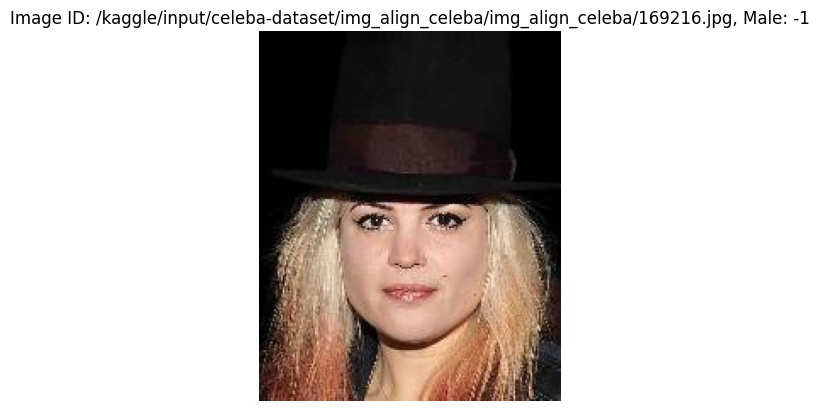

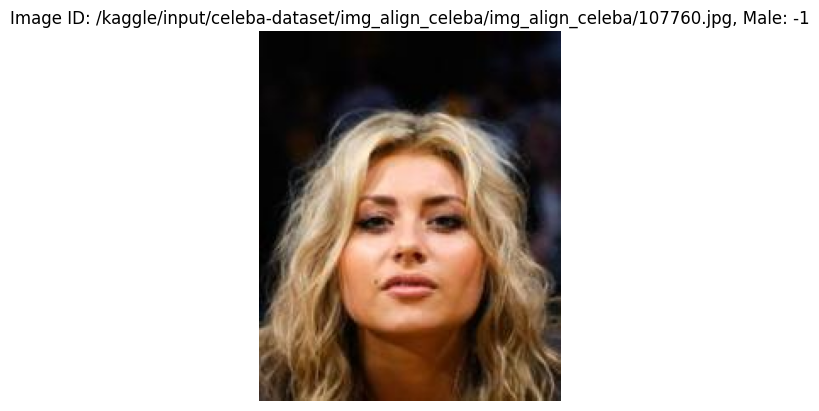

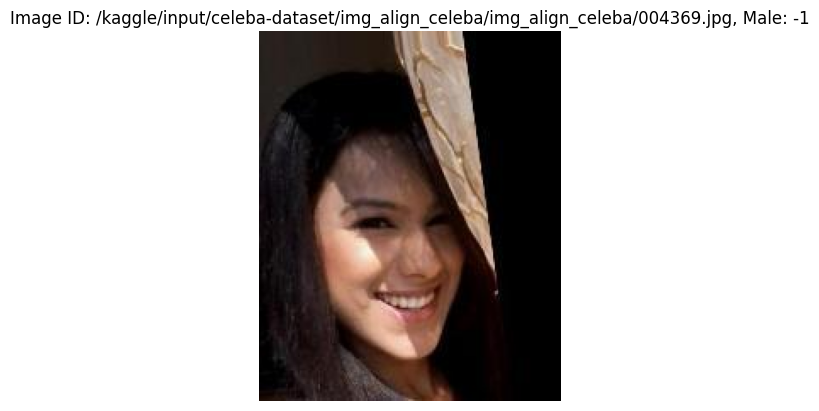

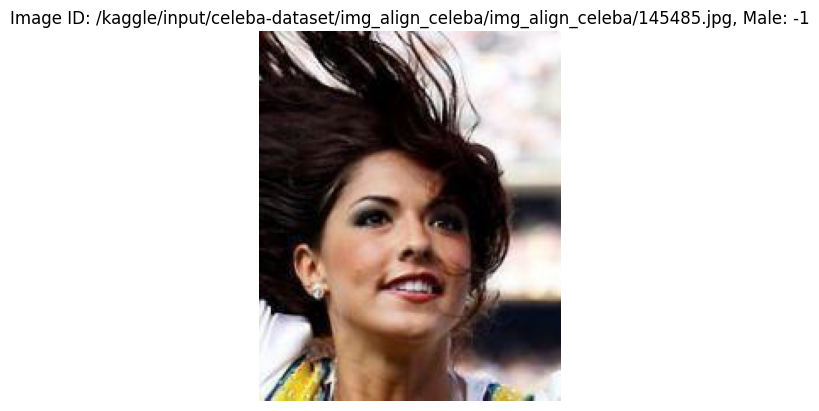

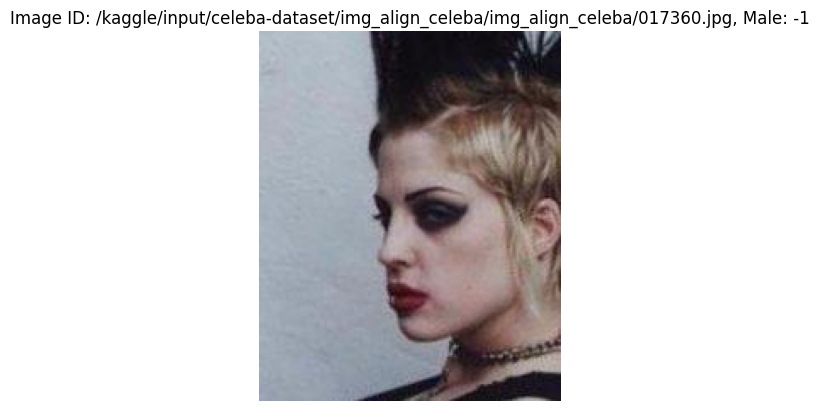

In [20]:
# prompt: show random images in df

import matplotlib.pyplot as plt
import random

# Select a random sample of images
num_images_to_show = 5  # Change this to show more or fewer images
random_indices = random.sample(range(len(df)), num_images_to_show)
random_images = df.iloc[random_indices]

# Display the images
for index, row in random_images.iterrows():
    image_path = row['image_id']
    try:
        img = plt.imread(image_path)
        plt.imshow(img)
        plt.title(f"Image ID: {row['image_id']}, Male: {row['Male']}")
        plt.axis('off')  # Turn off axis labels
        plt.show()
    except FileNotFoundError:
        print(f"Image file not found: {image_path}")
    except Exception as e:
        print(f"Error displaying image {image_path}: {e}")


In [21]:
# prompt: remove 1/2 rows of df

import pandas as pd
# Assuming 'df' is your DataFrame from the previous code
# Example usage (replace with your actual df)
#df = pd.DataFrame({'A': range(10)})

# Calculate the number of rows to remove
rows_to_remove = len(df) * 0.9

# Randomly select indices to remove
indices_to_remove = df.sample(n=int(rows_to_remove)).index

# Remove the selected rows
df = df.drop(indices_to_remove)

# Print the reduced DataFrame
df


,image_id,Male
2,/kaggle/input/celeba-dataset/img_align_celeba/...,1
5,/kaggle/input/celeba-dataset/img_align_celeba/...,-1
10,/kaggle/input/celeba-dataset/img_align_celeba/...,-1
15,/kaggle/input/celeba-dataset/img_align_celeba/...,1
16,/kaggle/input/celeba-dataset/img_align_celeba/...,-1
...,...,...
202539,/kaggle/input/celeba-dataset/img_align_celeba/...,-1
202550,/kaggle/input/celeba-dataset/img_align_celeba/...,-1
202551,/kaggle/input/celeba-dataset/img_align_celeba/...,1
202565,/kaggle/input/celeba-dataset/img_align_celeba/...,1


In [22]:
df['Male'].value_counts()

,count
Male,
-1,11874
1,8386


In [23]:
# prompt: split random df

from sklearn.model_selection import train_test_split

# Assuming 'df' is your DataFrame
train_df, test_df = train_test_split(df, test_size=0.25, random_state=42)
print(f"Train set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")


Train set size: 15195
Test set size: 5065


In [24]:
train_df['Male'] = train_df['Male'].astype(str)
test_df['Male'] = test_df['Male'].astype(str)

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Set the image size and batch size
image_size = (75, 75)
batch_size = 128

# Create an ImageDataGenerator object with data augmentation options for image preprocessing
datagen = ImageDataGenerator(
    rescale=1./255,
    # rotation_range=45,
    # width_shift_range=0.2,
    # height_shift_range=0.2,
    # shear_range=0.2,
    # zoom_range=0.2,
    # horizontal_flip=True,
    # fill_mode='nearest'
)


# Create a generator for the training data
train_generator = datagen.flow_from_dataframe(
    train_df,
    x_col='image_id',
    y_col='Male',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Create a generator for the test data
test_generator = datagen.flow_from_dataframe(
    test_df,
    x_col='image_id',
    y_col='Male',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 15195 validated image filenames belonging to 2 classes.
Found 5065 validated image filenames belonging to 2 classes.


In [26]:
from tensorflow.keras.applications import InceptionV3
inc_model = InceptionV3(weights='imagenet',
                        include_top=False,
                        input_shape=(75, 75, 3))

print("number of layers:", len(inc_model.layers))

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
number of layers: 311


In [27]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model # Import the Model class
from tensorflow.keras.optimizers import SGD # Import the SGD optimizer
#Adding custom Layers
x = inc_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation="relu")(x)
x = Dropout(0.5)(x)
x = Dense(512, activation="relu")(x)
predictions = Dense(2, activation="softmax")(x)

In [28]:
# creating the final model
model_ = Model(inputs=inc_model.input, outputs=predictions)

# Lock initial layers to do not be trained
for layer in model_.layers[:52]:
    layer.trainable = False

# compile the model
model_.compile(optimizer=SGD( momentum=0.9)
                    , loss='categorical_crossentropy'
                    , metrics=['accuracy'])

In [29]:
#https://keras.io/models/sequential/ fit generator
from tensorflow.keras.callbacks import ModelCheckpoint # Import ModelCheckpoint
checkpointer = ModelCheckpoint(filepath='weights.best.inc.male.keras',
                               verbose=1, save_best_only=True)

In [30]:
hist = model_.fit(train_generator
                     , validation_data=test_generator
                      , epochs= 15
                      , callbacks=[checkpointer]
                      , verbose=1
                    )

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6931 - loss: 0.5400
Epoch 1: val_loss improved from inf to 0.39602, saving model to weights.best.inc.male.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.6941 - loss: 0.5387 - val_accuracy: 0.8894 - val_loss: 0.3960
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9504 - loss: 0.1466
Epoch 2: val_loss improved from 0.39602 to 0.32270, saving model to weights.best.inc.male.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 36s 234ms/step - accuracy: 0.9504 - loss: 0.1466 - val_accuracy: 0.9076 - val_loss: 0.3227
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9796 - loss: 0.0666
Epoch 3: val_loss improved from 0.32270 to 0.17124, saving model to weights.best.inc.male.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 29s 240ms/step - accuracy: 0.9796 - loss: 0.0665 - val_accuracy: 0.9386 - val_loss: 0.1712
Epoch 4/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9922 - loss: 0.0257
Epoch 4: 

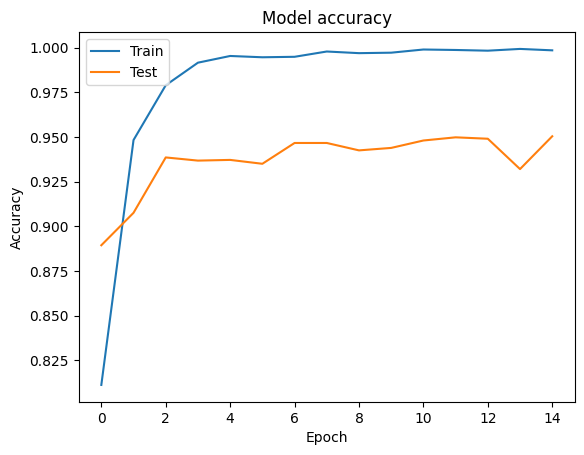

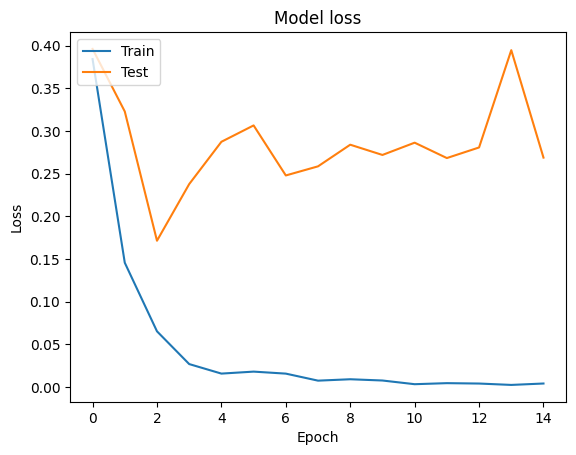

In [31]:
# prompt: plot history model

import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


In [34]:
# prompt: show img with path

import matplotlib.pyplot as plt
import os



def show_image_with_path(image_path):
    try:
        img = plt.imread(image_path)
        plt.imshow(img)
        plt.title(f"Image Path: {image_path}")
        plt.axis('off')  # Turn off axis labels
        plt.show()
    except FileNotFoundError:
        print(f"Image file not found: {image_path}")
    except Exception as e:
        print(f"Error displaying image {image_path}: {e}")






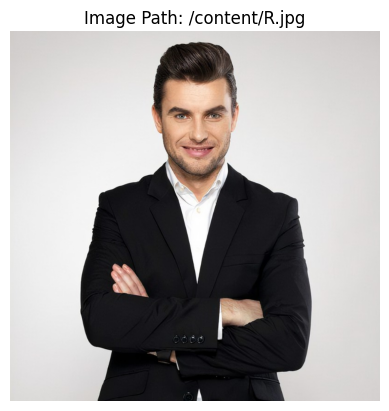

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Prediction: Female
Prediction probabilities: [[0.60956275 0.39043725]]


In [35]:
# prompt: predict with model

import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load the trained model
model = load_model('weights.best.inc.male.keras')

def predict_image(image_path):
    show_image_with_path(image_path)
    img = image.load_img(image_path, target_size=(75, 75))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.

    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction)

    if predicted_class == 0:
        result = "Female"
    else:
        result = "Male"

    return result, prediction

# Example usage:
result, prediction = predict_image('/content/R.jpg')
print(f"Prediction: {result}")
print(f"Prediction probabilities: {prediction}")


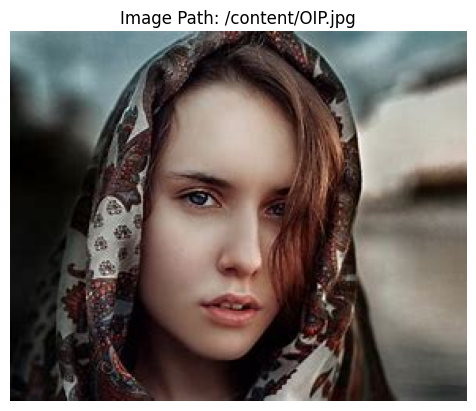

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Prediction: Female
Prediction probabilities: [[0.9863668  0.01363315]]


In [48]:
# Example usage:
result, prediction = predict_image('/content/OIP.jpg')
print(f"Prediction: {result}")
print(f"Prediction probabilities: {prediction}")

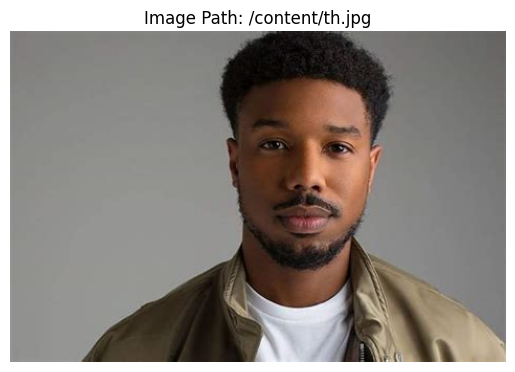

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prediction: Male
Prediction probabilities: [[0.09432996 0.90567   ]]


In [41]:
# Example usage:
result, prediction = predict_image('/content/th.jpg')
print(f"Prediction: {result}")
print(f"Prediction probabilities: {prediction}")

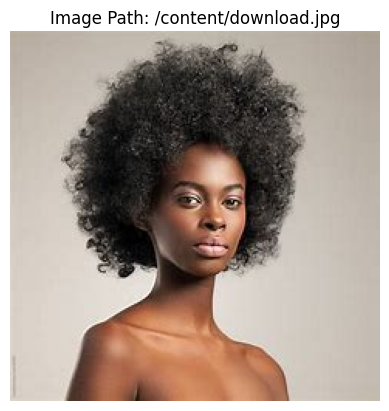

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Prediction: Female
Prediction probabilities: [[0.90740776 0.09259228]]


In [44]:
# Example usage:
result, prediction = predict_image('/content/download.jpg')
print(f"Prediction: {result}")
print(f"Prediction probabilities: {prediction}")

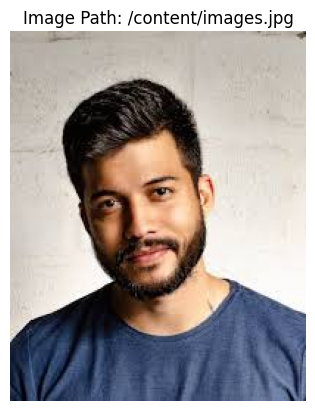

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Prediction: Male
Prediction probabilities: [[0.00687519 0.9931248 ]]


In [49]:
# Example usage:
result, prediction = predict_image('/content/images.jpg')
print(f"Prediction: {result}")
print(f"Prediction probabilities: {prediction}")